In [1]:
from obb_anns import OBBAnns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import numpy as np
from PIL import Image
import os

In [2]:
# Load train and test sets
train = OBBAnns('../data/ds2_dense/deepscores_train.json')
train.load_annotations()

test = OBBAnns('../data/ds2_dense/deepscores_test.json')
test.load_annotations()

loading ann_info...
done! t=4.03s
loading ann_info...
done! t=1.51s


In [3]:
train_imgs = train.img_info
test_imgs = test.img_info

print(f"Training images: {len(train_imgs)}")
print(f"Test images: {len(test_imgs)}")
print(f"Total categories: {len(train.cat_info)}")

Training images: 1362
Test images: 352
Total categories: 208


### Image Dimensions
Images vary significantly in size (width: 1,597–3,842px, height: 2,259–5,434px, mean ~2,059×2,912px), reflecting different page layouts and score complexities. All images are high resolution (rendered at 400 DPI per the paper). Full-size images will probably need to be processed as crops or resized.

In [4]:
# Check image dimensions
widths, heights = [], []
for img in train.img_info:
    widths.append(img['width'])
    heights.append(img['height'])

print(f"Image widths  — min: {min(widths)}, max: {max(widths)}, mean: {sum(widths)//len(widths)}")
print(f"Image heights — min: {min(heights)}, max: {max(heights)}, mean: {sum(heights)//len(heights)}")

Image widths  — min: 1597, max: 3842, mean: 2059
Image heights — min: 2259, max: 5434, mean: 2912


## Sample Visualizations
The following images show annotated pages from the training set with bounding boxes overlaid and color coded by symbol class. These are rendered using the OBBAnns toolkit's built-in visualization method.

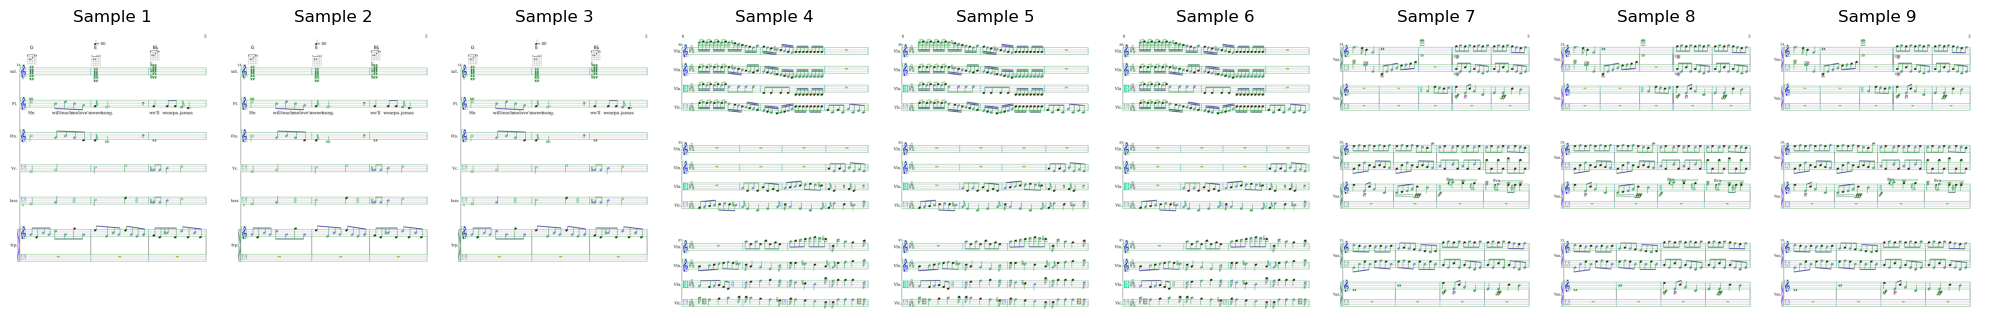

In [5]:
for i in [0, 1, 2]:
    train.visualize(img_idx=i, out_dir='eda_outputs', show=False)

output_files = sorted(os.listdir('eda_outputs'))
fig, axes = plt.subplots(1, len(output_files), figsize=(20, 8))
for i, (ax, fname) in enumerate(zip(axes, output_files)):
    img = Image.open(f'eda_outputs/{fname}')
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f'Sample {i+1}')
plt.tight_layout()
plt.show()


### Observations from Sample Images
- The dataset contains orchestral and ensemble scores with multiple instruments per line (violin, viola, cello, piano). This is more complex than the beginner/intermediate single-instrument sheet music that is the target use case, but represents the training distribution
- Both treble (clefG) and bass (clefF) clefs are present across the different samples, which means the dataset will work for handling both clef types
- Some pages contain out-of-scope elements such as guitar chord diagrams, lyrics, and tempo markings which will be treated as noise
- The bounding boxes are dense and overlapping in some of the more complex passages, which will be a challenge for detection

## Annotation Sets

In [6]:
# Check annotation sets available
print(train.annotation_sets)

# Look at a sample category entry
sample_cats = list(train.cat_info.items())[:5]
for cat_id, cat in sample_cats:
    print(cat_id, cat)

['deepscores', 'muscima++']
1 {'name': 'brace', 'annotation_set': 'deepscores', 'color': 1}
137 {'name': 'brace', 'annotation_set': 'muscima++', 'color': 1}
2 {'name': 'ledgerLine', 'annotation_set': 'deepscores', 'color': 2}
138 {'name': 'legerLine', 'annotation_set': 'muscima++', 'color': 2}
3 {'name': 'repeatDot', 'annotation_set': 'deepscores', 'color': 7}


### Observation
The dataset contains two annotation sets: `deepscores` and `muscima++`, which means there are 208 total categories (136 deepscores + 72 muscima++). The muscima++ set is supposed to be for handwritten music and uses slightly different class names for the same symbols (`legerLine` vs `ledgerLine`). Since my project is only using printed music, I will filter to only the `deepscores` annotation set so that it's not double counting.


## Class Distribution

In [7]:
# Get all annotations as dataframe
all_anns = train.ann_info

# Get deepscores-only categories
deepscores_cats = {cat_id: cat for cat_id, cat in train.cat_info.items() 
                   if cat['annotation_set'] == 'deepscores'}
deepscores_cat_ids = set(deepscores_cats.keys())

# Count instances per class - ann_info is a DataFrame
# cat_id column contains lists, first element is deepscores cat_id
class_counts = {}
for _, ann in all_anns.iterrows():
    cat_id = int(ann['cat_id'][0])
    if cat_id in deepscores_cat_ids:
        name = deepscores_cats[cat_id]['name']
        class_counts[name] = class_counts.get(name, 0) + 1

# Sort by count
class_counts = dict(sorted(class_counts.items(), key=lambda x: x[1], reverse=True))
print(f"Total unique classes found in training set: {len(class_counts)}")
print(f"Total annotated instances: {sum(class_counts.values())}")

Total unique classes found in training set: 115
Total annotated instances: 889833


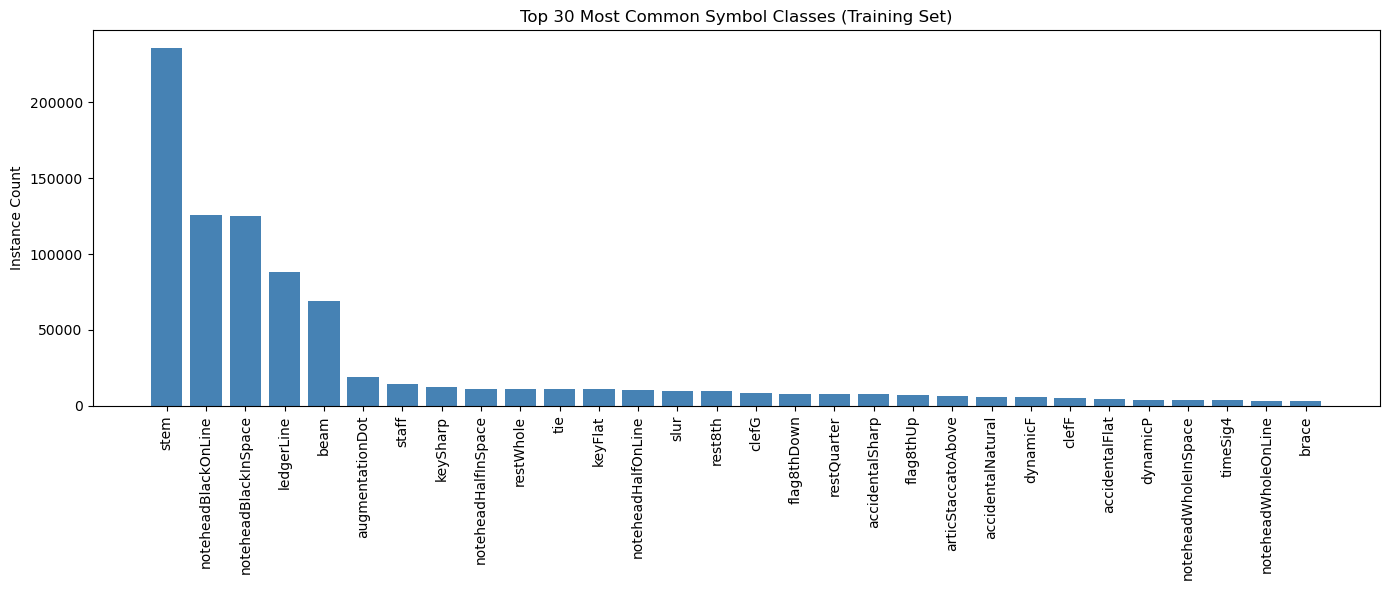

In [8]:
top_30 = dict(list(class_counts.items())[:30])

plt.figure(figsize=(14, 6))
plt.bar(top_30.keys(), top_30.values(), color='steelblue')
plt.xticks(rotation=90)
plt.title('Top 30 Most Common Symbol Classes (Training Set)')
plt.ylabel('Instance Count')
plt.tight_layout()
plt.show()

## Class Distribution Analysis

I am going to look at the full distribution of all 115 classes found in the training set to decide which ones are in the scope of the analysis. The plot above shows the top 30. There is a long-tail distribution where a handful of classes (stem, noteheads, ledger lines, beams) dominate while most classes have very few instances.

In [9]:
# Print all 115 classes sorted by count
print(f"{'Class':<40} {'Count':>8}")
print("-" * 50)
for cls, count in class_counts.items():
    print(f"{cls:<40} {count:>8,}")

Class                                       Count
--------------------------------------------------
stem                                      235,695
noteheadBlackOnLine                       125,497
noteheadBlackInSpace                      125,410
ledgerLine                                 88,316
beam                                       69,016
augmentationDot                            18,723
staff                                      14,496
keySharp                                   12,685
noteheadHalfInSpace                        11,297
restWhole                                  11,239
tie                                        11,034
keyFlat                                    10,954
noteheadHalfOnLine                         10,718
slur                                        9,937
rest8th                                     9,565
clefG                                       8,332
flag8thDown                                 8,053
restQuarter                                 7,579

### In-Scope Symbol Classes
Based on the full class list above, I am going to define the following symbols as in-scope for this project. Selection criteria: (1) directly necessary for pitch or rhythm inference, (2) sufficient training instances, (3) present in beginner/intermediate printed music.

**Deliberately excluded (future work):**
- tie — affects rhythm for playing but is pretty complex; noted as a limitation
- repeatDot — correct playing would require repeat logic; out of scope for v1
- tuplet3 (1,985 instances) — tuplets have a more complicated rhythm; excluded despite frequency
- slur — expressive marking only, does not affect pitch or rhythm in MIDI output
- dynamics (dynamicF, dynamicP, dynamicM, etc.) — out of scope as decided in problem framing
- fingering — performance annotation only, irrelevant to MIDI output
- ornaments (trill, mordent, turn) — expressive, complex to actually play, out of scope for v1

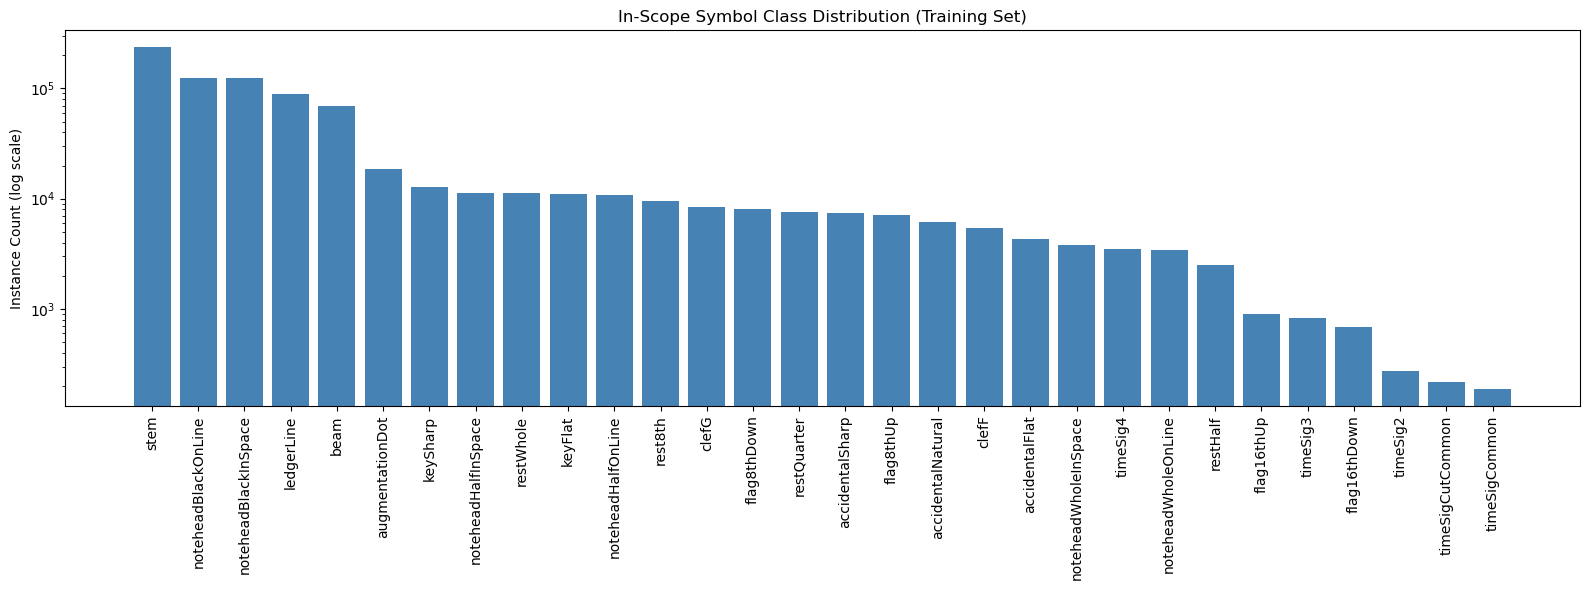


Total in-scope instances: 799,893
In-scope classes: 30


In [10]:
in_scope = [
    'noteheadBlackOnLine', 'noteheadBlackInSpace',
    'noteheadHalfOnLine', 'noteheadHalfInSpace',
    'noteheadWholeOnLine', 'noteheadWholeInSpace',
    'ledgerLine', 'stem', 'beam',
    'flag8thDown', 'flag8thUp',
    'flag16thDown', 'flag16thUp',
    'restQuarter', 'restHalf', 'restWhole', 'rest8th',
    'clefG', 'clefF',
    'timeSig4', 'timeSig3', 'timeSig2', 'timeSigCommon', 'timeSigCutCommon',
    'accidentalSharp', 'accidentalFlat', 'accidentalNatural',
    'keySharp', 'keyFlat',
    'augmentationDot'
]

in_scope_counts = {cls: class_counts.get(cls, 0) for cls in in_scope}
in_scope_sorted = dict(sorted(in_scope_counts.items(), key=lambda x: x[1], reverse=True))

plt.figure(figsize=(16, 6))
bars = plt.bar(in_scope_sorted.keys(), in_scope_sorted.values(), color='steelblue')
plt.xticks(rotation=90)
plt.title('In-Scope Symbol Class Distribution (Training Set)')
plt.ylabel('Instance Count (log scale)')
plt.yscale('log')  # log scale because stem/noteheads dwarf everything else
plt.tight_layout()
plt.show()

print(f"\nTotal in-scope instances: {sum(in_scope_sorted.values()):,}")
print(f"In-scope classes: {len(in_scope)}")

### In-Scope Class Counts — Observations
- Noteheads (black, half, whole — on line and in space) makeup the majority 
  of musically meaningful symbols and occur the most frequently (3k–125k)
- Stems and beams are the most common symbols overall, which makes sense as nearly 
  every note has a stem and beamed groups are common
- Clefs: clefG (treble, 8,332) and clefF (bass, 5,405) are both well represented
- Time signatures: timeSig4 dominates (3,492) as expected — 4/4 is by far the most 
  common time signature in the music
- Key signatures: keySharp (12,685) and keyFlat (10,954) are common enough to handle reliably
- Class imbalance is significant: stems have 235k instances vs timeSig2 with only 274. 
  This will need to be accounted for during training (e.g. weighted loss, careful evaluation per class)
- Known limitation: the dataset is fully synthetic (rendered from MusicXML), meaning 
  images are perfectly clean with no scanning artifacts, noise, or real-world variation. 
  Models trained on this data may not generalize well to real scanned sheet music.